# 🧪 Simulate Notebook — QICK Mock Experiments

Run **all experiments without hardware** using `simulate=True`.  
No QICK board, no Pyro, no Yoko — just numpy + matplotlib.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.ncfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)
print(f"Config loaded for {qubit}, res_freq_ge = {run_cfg['res_freq_ge']} MHz")

No Labber module
Config loaded for Q1, res_freq_ge = 5351.559 MHz


---
# GE State Experiments

## s001 — Time of Flight

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


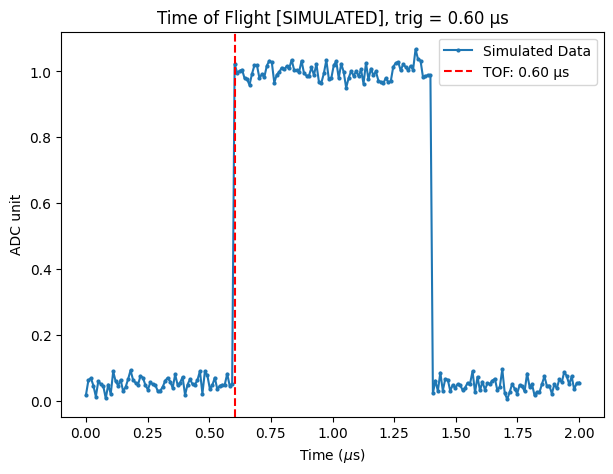

(array([-3.66324633e-04-1.65722137e-02j,  5.16821807e-02+3.38853042e-02j,
         6.21472817e-02-2.82978166e-02j,  4.50266983e-02-7.30415603e-03j,
         1.03369314e-02+6.47766577e-03j,  5.15844286e-02+2.89684326e-02j,
         4.96904333e-02+2.25509301e-03j,  1.60654074e-02+4.08626624e-02j,
         5.65061761e-03+3.38947249e-03j,  4.87464959e-02-1.58827666e-03j,
        -2.75435582e-03+1.95154802e-02j,  6.24165152e-02+6.26889003e-02j,
         4.49845412e-02+3.66154918e-02j,  4.57072137e-02-4.49815616e-04j,
         6.05860646e-02+1.72148968e-02j,  2.85520017e-02-8.51016681e-04j,
         2.12815492e-02+3.46736699e-02j,  6.16156338e-02+1.90294612e-02j,
         9.03880708e-02+1.60976494e-02j,  5.80857078e-02+2.53756279e-02j,
         3.73305042e-02-3.89383241e-02j,  3.61483960e-02-3.05622993e-02j,
         7.49092893e-02-2.29677117e-03j,  6.94282243e-02-2.37806069e-03j,
         3.95450748e-02+2.45008645e-02j,  3.23814600e-02+6.87813828e-03j,
         3.82576688e-02+4.01210849e-02

In [2]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update({
    "readout_length": 200,
})

tof = TOF(None, None, run_cfg)
tof.run(py_avg=10, simulate=True)

## s002 — Resonator Spectroscopy ge

c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\module_fitzcu.py:126: SyntaxWarning: invalid escape sequence '\k'
  plt.plot(x, asym_lorfunc(x, *pOpt), label=f"Fit, $\kappa$={pOpt[3]:.2f} MHz")
c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\module_fitzcu.py:197: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"$\chi=${(res2 - res1):.3f}, unit = MHz", fontsize=15)
c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\module_fitzcu.py:202: SyntaxWarning: invalid escape sequence '\k'
  x, asym_lorfunc(x, *pOpt1), label=f"fite, $\kappa$ = {pOpt1[3]:.2f}MHz"
c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\module_fitzcu.py:205: SyntaxWarning: invalid escape sequence '\k'
  x, asym_lorfunc(x, *pOpt2), label=f"fitg, $\kappa$ = {pOpt2[3]:.2f}MHz"
c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\module_fitzcu.py:414: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"T1 = {pOpt[3]:.2f} +-{p_sigma[3]:.2f}$\mu s$", fontsize=15)
c:\Users\zx123\

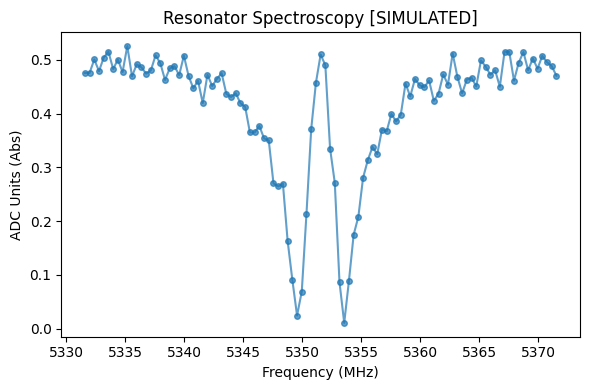

c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 5.3516, 'Qi': 1432, 'Ql': -608, 'absQc': -427, 'κ(MHz)': -8.8}
Fit result: [ 5.35158508e+09 -8.79895444e+06 -1.25357672e+07 -3.14091056e+00
  1.80821783e-01  4.57226054e-01 -9.33191009e-09]


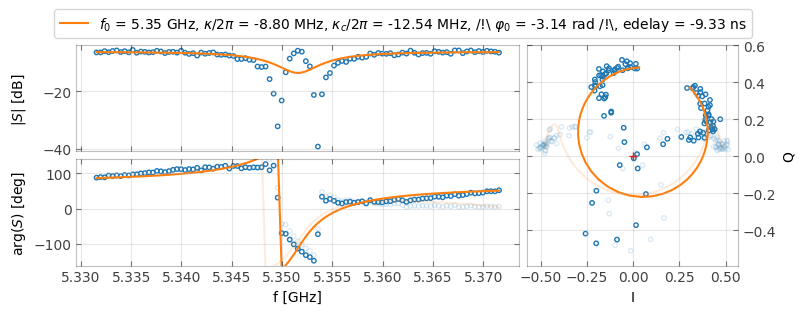

In [10]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

center = config_all.get_qubit(qubit)['res_freq_ge']
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 101),
    ("relax_delay", 0),
])

onetone = ResonatorSpec(None, None, run_cfg)
fres = onetone.run(py_avg=10, simulate=True,
                   x_pts=np.linspace(center - 20, center + 20, 101))
print(f"Fit result: {fres}")

## s002b — Resonator Punchout

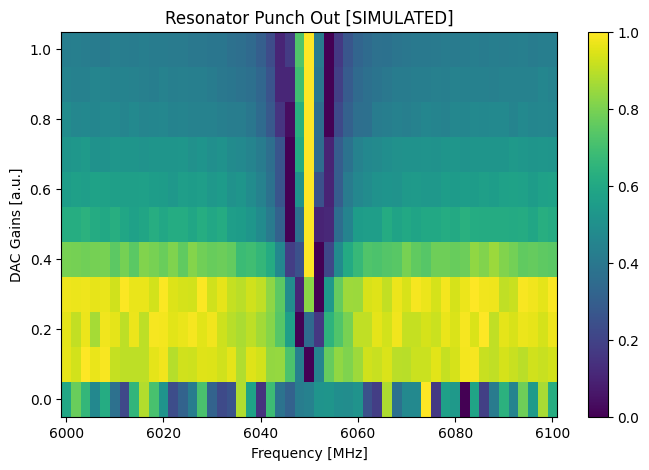

In [11]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

center = config_all.get_qubit(qubit)['res_freq_ge']
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("f_steps", 51),
    ("g_steps", 11),
])

po = Punchout(None, None, run_cfg)
po.run(py_avg=10, simulate=True)

## s003 — Qubit Spectroscopy ge

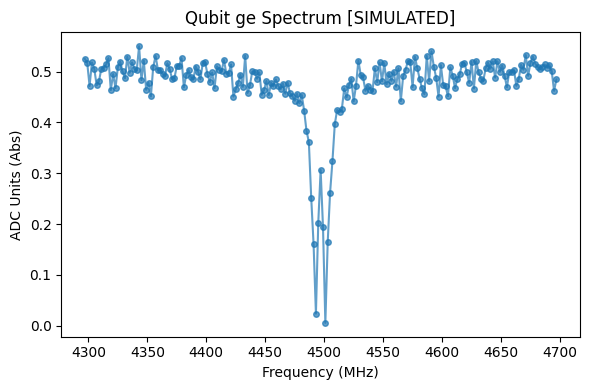

Qubit freq ge = 4497.165459 MHz


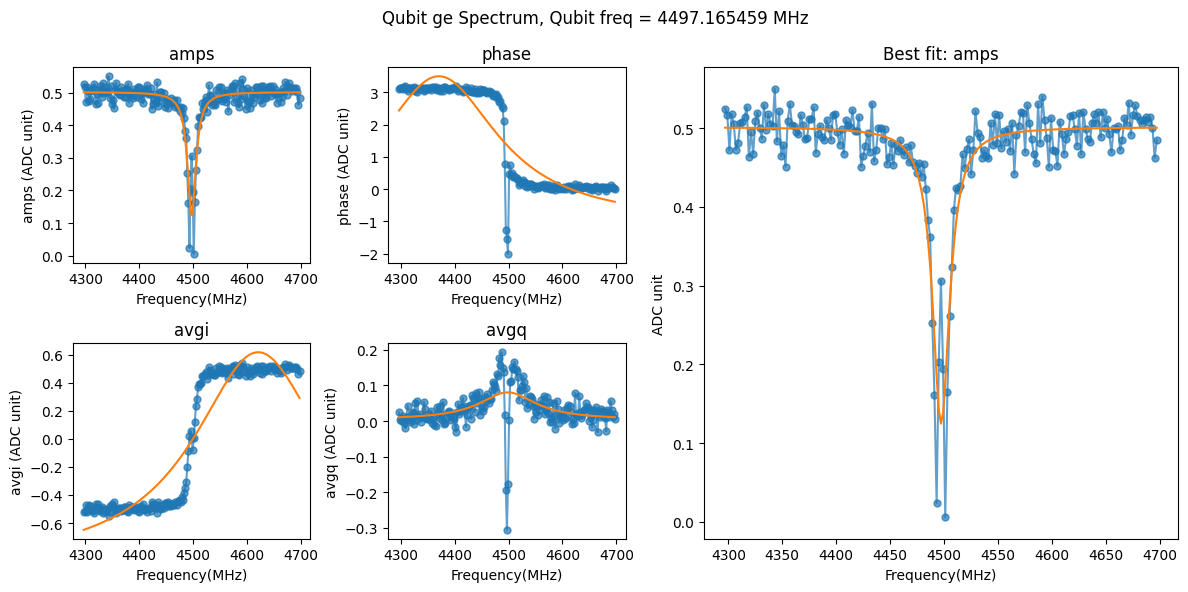

In [12]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = config_all.get_qubit(qubit)['qb_freq_ge']
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 201),
    ("qb_length_ge", 5),
    ("relax_delay", 1),
])

spectrum = QubitSpec(None, None, run_cfg)
f_ge = spectrum.run(py_avg=20, simulate=True,
                    x_pts=np.linspace(center - 200, center + 200, 201))
print(f"Qubit freq ge = {f_ge} MHz")

## s004 — Time Rabi ge

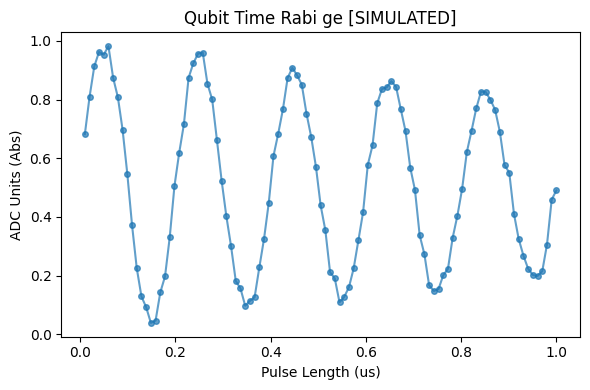

array([0.49633403, 4.99408875, 0.6255242 , 2.0268973 , 0.50137295])

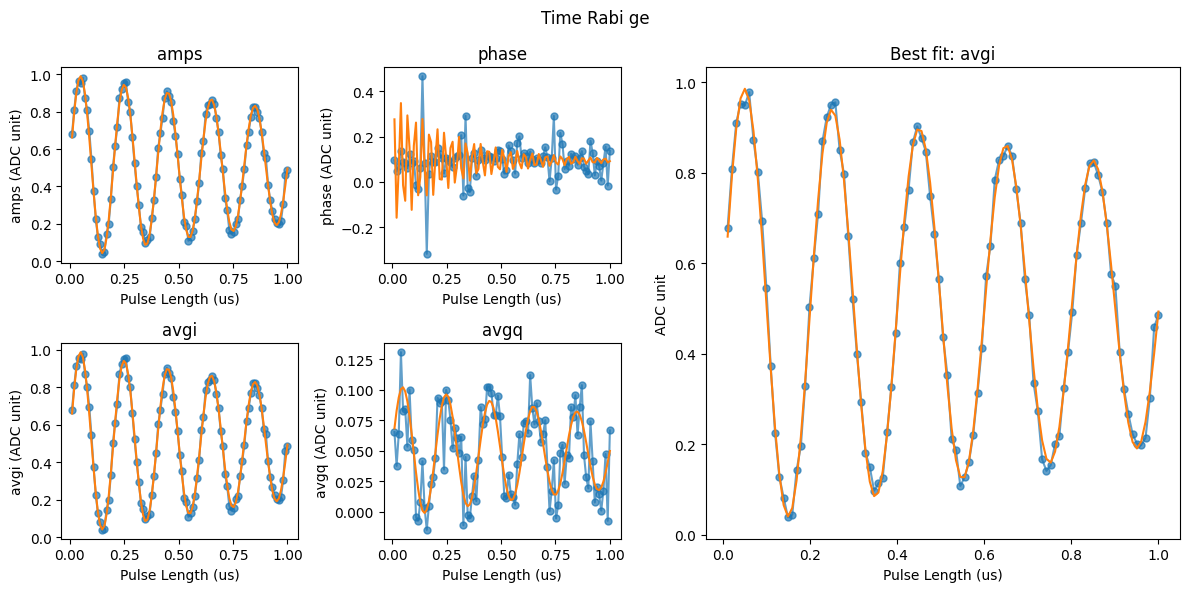

In [13]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("cooling", False),
    ("qb_gain_ge", 0.5),
])

trabi = TimeRabi(None, None, run_cfg)
trabi.run(py_avg=20, simulate=True,
          x_pts=np.linspace(0.01, 1, 101))

## s005 — Power Rabi ge

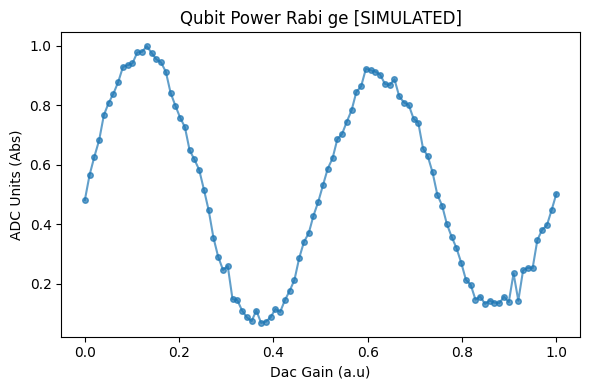

pi = 0.370472, pi/2 = 0.242063


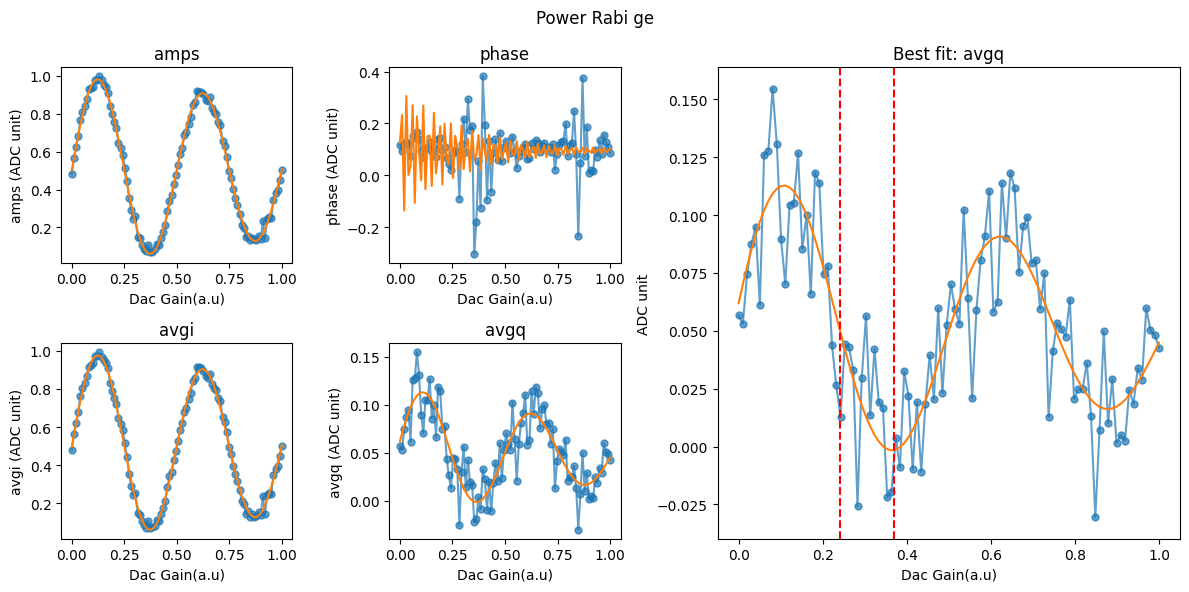

In [14]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("cooling", False),
])

prabi = PowerRabi(None, None, run_cfg)
pi_gain, pi2_gain = prabi.run(py_avg=20, simulate=True,
                              x_pts=np.linspace(0, 1, 100))
print(f"pi = {pi_gain}, pi/2 = {pi2_gain}")

## s005a — Amplified Amplitude Error

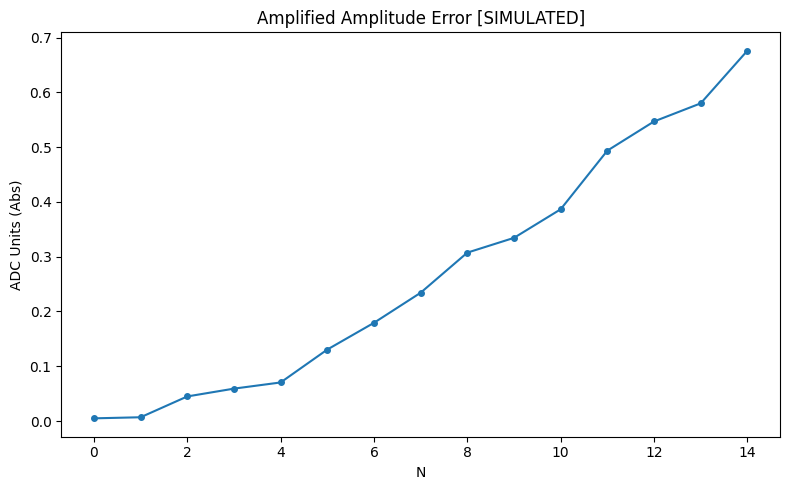

In [15]:
from qick_workspace.newscrip.s005a_AAE import AAE

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("AAE", "pi2"),
    ("pi2_gain_ge", 0.25),
])

aae = AAE(None, None, run_cfg)
aae.run(py_avg=20, iteration_count=15, simulate=True)

## s006 — Ramsey ge

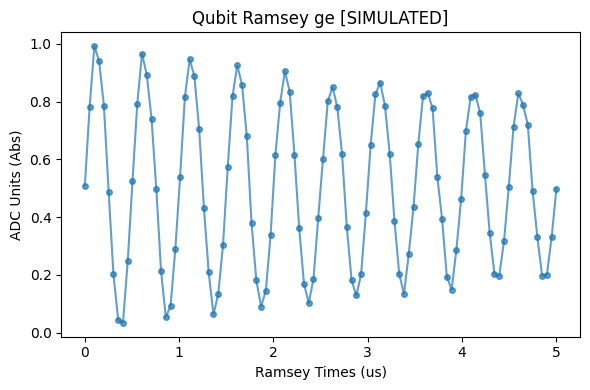

array([ 0.48848682,  2.00083276, -0.60697753, 10.78834935,  0.50044529])

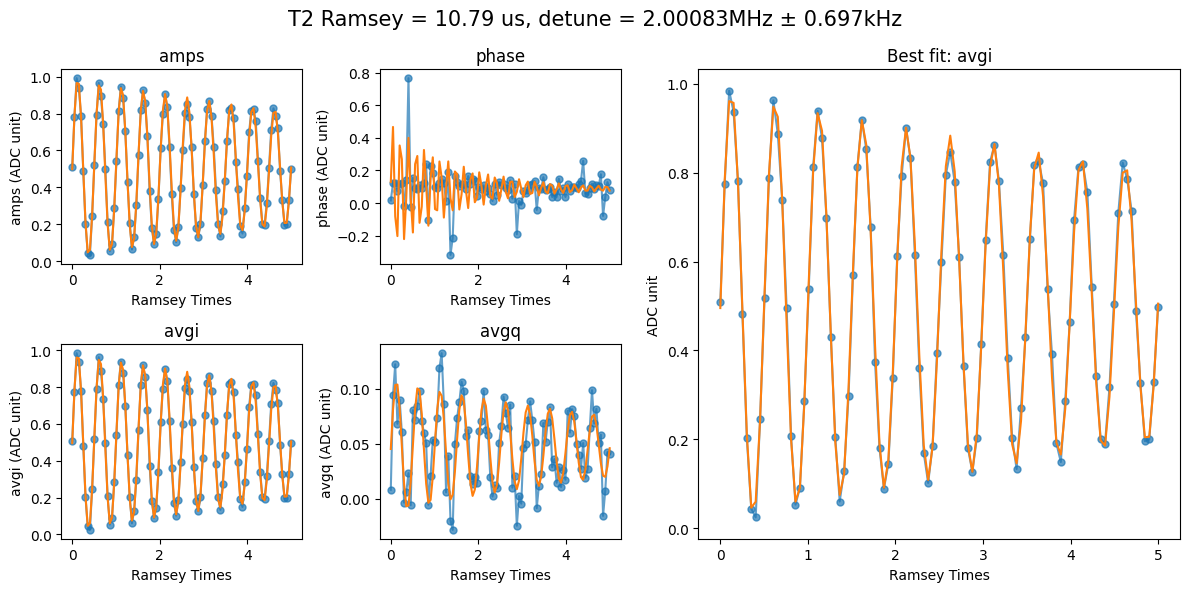

In [16]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("ramsey_freq", 2),
])

t2r = Ramsey(None, None, run_cfg)
t2r.run(py_avg=10, simulate=True,
        x_pts=np.linspace(0, 5, 100))

## s007 — Spin Echo ge

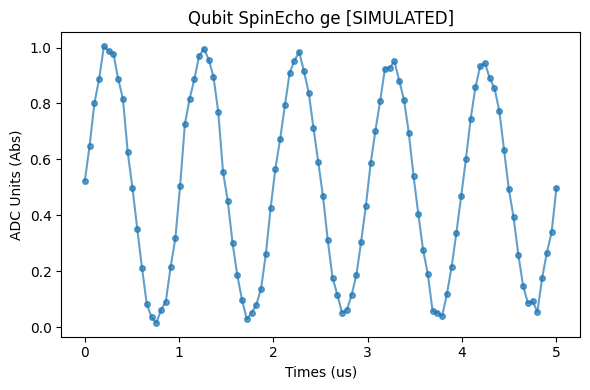

array([ 0.50238756,  1.00063392, -1.23872115, 29.51544742,  0.49779792])

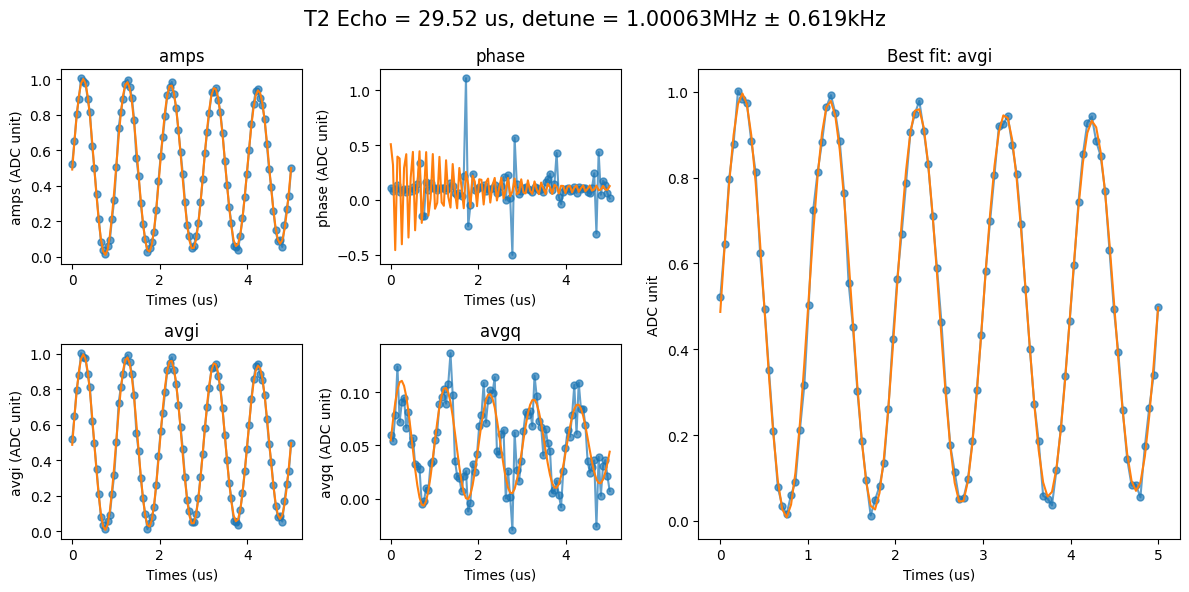

In [17]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("ramsey_freq", 1),
    ("cooling", False),
])

t2e = SpinEcho(None, None, run_cfg)
t2e.run(py_avg=20, simulate=True,
        x_pts=np.linspace(0, 5, 100))

## s008 — T1 ge

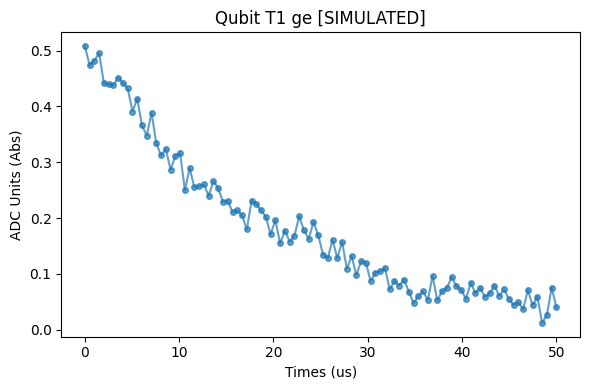

array([6.84958241e-03, 5.04079582e-01, 1.89432354e+01])

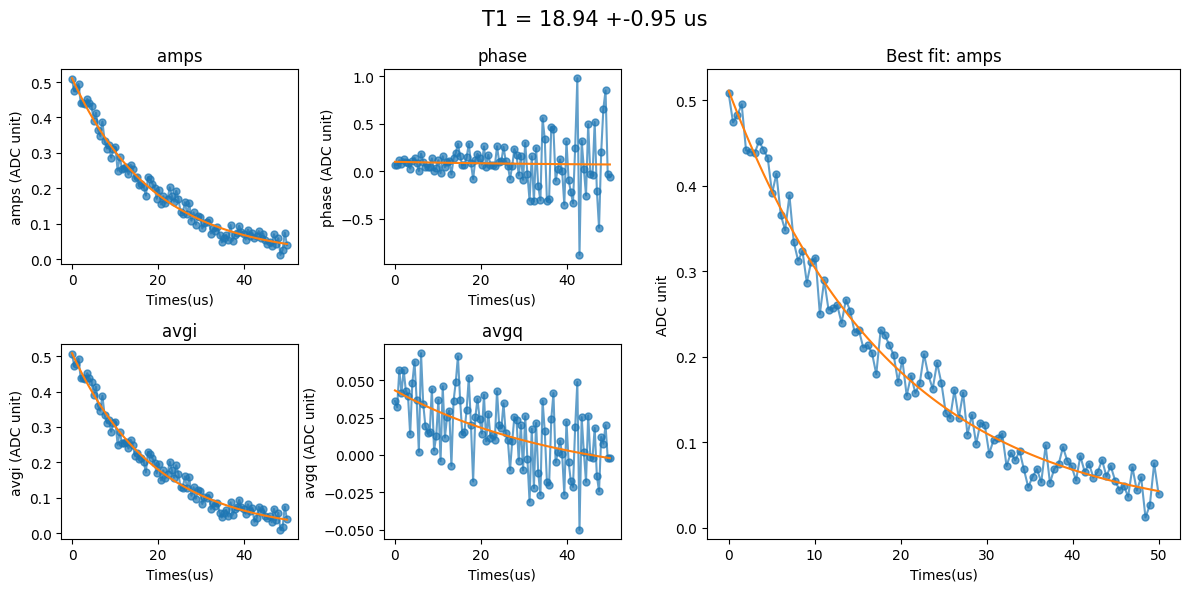

In [18]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("relax_delay", 50),
    ("cooling", False),
])

t1 = T1(None, None, run_cfg)
t1.run(py_avg=50, simulate=True,
       x_pts=np.linspace(0, 50, 100))

---
# EF State Experiments

## s009 — Resonator Spectroscopy ef

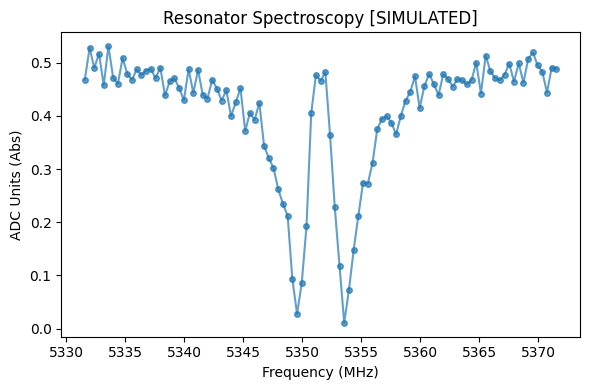

c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 5.3516, 'Qi': 1370, 'Ql': -599, 'absQc': -417, 'κ(MHz)': -8.94}
Fit result ef: [ 5.35163745e+09 -8.93639615e+06 -1.28430910e+07 -3.13875083e+00
 -4.42392985e-01 -2.06537946e-01 -9.21610511e-09]


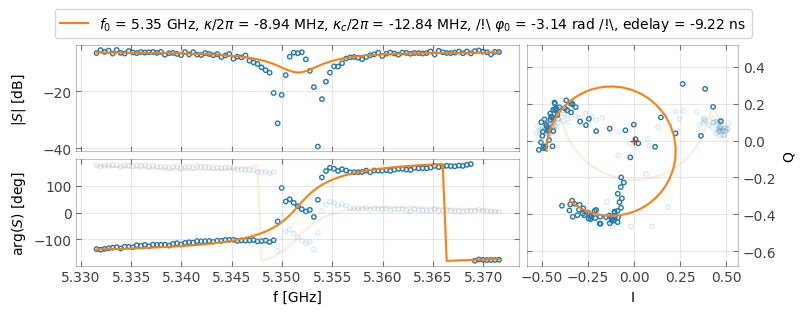

In [19]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

center = config_all.get_qubit(qubit)['res_freq_ge']
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 101),
    ("relax_delay", 0),
])

onetone_ef = ResonatorSpec_ef(None, None, run_cfg)
fres_ef = onetone_ef.run(py_avg=10, simulate=True,
                         x_pts=np.linspace(center - 20, center + 20, 101))
print(f"Fit result ef: {fres_ef}")

## s010 — Qubit Spectroscopy ef

In [ ]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center_ef = config_all.get_qubit(qubit).get('qb_freq_ef', 4200)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 201),
    ("relax_delay", 1),
])

spec_ef = QubitSpec_ef(None, None, run_cfg)
f_ef = spec_ef.run(py_avg=20, simulate=True,
                   x_pts=np.linspace(center_ef - 200, center_ef + 200, 201))
print(f"Qubit freq ef = {f_ef} MHz")

## s011 — Power Rabi ef

In [ ]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("cooling", False),
])

prabi_ef = PowerRabi_ef(None, None, run_cfg)
result_ef = prabi_ef.run(py_avg=20, simulate=True,
                         x_pts=np.linspace(0, 1, 100))
print(f"pi/pi2 ef gains: {result_ef}")

## s012 — Ramsey ef

In [ ]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("ramsey_freq", 2),
])

ramsey_ef = Ramsey_ef(None, None, run_cfg)
ramsey_ef.run(py_avg=10, simulate=True,
              x_pts=np.linspace(0, 5, 100))

## s013 — T1 ef

In [ ]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)
run_cfg.update([
    ("steps", 100),
    ("relax_delay", 50),
    ("cooling", False),
])

t1_ef = T1_ef(None, None, run_cfg)
t1_ef.run(py_avg=50, simulate=True,
          x_pts=np.linspace(0, 50, 100))

---
# Special Experiments

## s000 — Single Shot Readout

In [20]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)
ss = SingleShot_gef(None, None, run_cfg)
data = ss.run(SHOTS=1000, shot_f=False, simulate=True)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data["Ig"], data["Qg"], s=1, alpha=0.3, label="Ground")
ax.scatter(data["Ie"], data["Qe"], s=1, alpha=0.3, label="Excited")
ax.set_xlabel('I'); ax.set_ylabel('Q')
ax.set_title('Single Shot IQ [SIMULATED]')
ax.legend(); ax.set_aspect('equal')
plt.show()

c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\scrip\s000_SingleShot_prog.py:435: SyntaxWarning: invalid escape sequence '\o'
  fid_title = "$\overline{F}_{ge}$" if fid_avg else "$F_{ge}$"
c:\Users\zx123\Desktop\SQC_soc-main\qick_workspace\scrip\s000_SingleShot_prog.py:435: SyntaxWarning: invalid escape sequence '\o'
  fid_title = "$\overline{F}_{ge}$" if fid_avg else "$F_{ge}$"


ModuleNotFoundError: No module named 'Pyro4'

### SingleShot with f-state

In [ ]:
data_f = ss.run(SHOTS=1000, shot_f=True, simulate=True)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data_f["Ig"], data_f["Qg"], s=1, alpha=0.3, label="Ground")
ax.scatter(data_f["Ie"], data_f["Qe"], s=1, alpha=0.3, label="Excited")
ax.scatter(data_f["If"], data_f["Qf"], s=1, alpha=0.3, label="f-state")
ax.set_xlabel('I'); ax.set_ylabel('Q')
ax.set_title('Single Shot g/e/f [SIMULATED]')
ax.legend(); ax.set_aspect('equal')
plt.show()

## s014 — AllXY

In [ ]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)
allxy = AllXY(None, None, run_cfg)
allxy.run(py_avg=20, simulate=True)
allxy.plot()

## s015 — Randomized Benchmarking

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
rb = RandomizedBenchmarking(None, None, run_cfg)
rb.run(py_avg=5, max_circuit_depth=50, delta_clifford=5,
       number_sample=10, simulate=True)

plt.figure(figsize=(8, 5))
epc, epc_err, p, p_err = rb.plot("Simulated RB", color="blue")
plt.xlabel('Clifford Depth')
plt.ylabel('|IQ| Average')
plt.title('Randomized Benchmarking [SIMULATED]')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## s016 — State Tomography

In [ ]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

run_cfg = config_all.get_qubit(qubit)
tomo = Tomography(None, None, run_cfg)
tomo.run(py_avg=20, prep_pulse_name="x180_ge", simulate=True)
tomo.plot(plot_type="2d")

In [ ]:
# 3D bar plot
tomo.plot(plot_type="3d")

---
## ✅ Summary

All 19 experiments ran in `simulate=True` mode using `ncfg.config_list` (Q1 config):
- **GE**: TOF, ResSpec, Punchout, QubitSpec, TimeRabi, PowerRabi, AAE, Ramsey, SpinEcho, T1
- **EF**: ResSpec_ef, QubitSpec_ef, PowerRabi_ef, Ramsey_ef, T1_ef
- **Special**: SingleShot (g/e + g/e/f), AllXY, RB, Tomography

No hardware was required. All data came from `mock_signals.py`.